# Monte Carlo Experiments with `scipy.stats`

1. A tour of `scipy.stats` distributions, using the Titanic passenger data (from `seaborn`) for the empirical ones.
2. Fitting distributions to passenger ages and testing the fit.
3. A Monte Carlo estimate of the risk that a cost-saving project misses its target.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

RANDOM_STATE = 31415
rng = np.random.default_rng(RANDOM_STATE)

titanic = sns.load_dataset("titanic")  # downloaded from the seaborn-data repo on first use
ages = titanic["age"].dropna()         # only the age column, without missing values

## Distributions

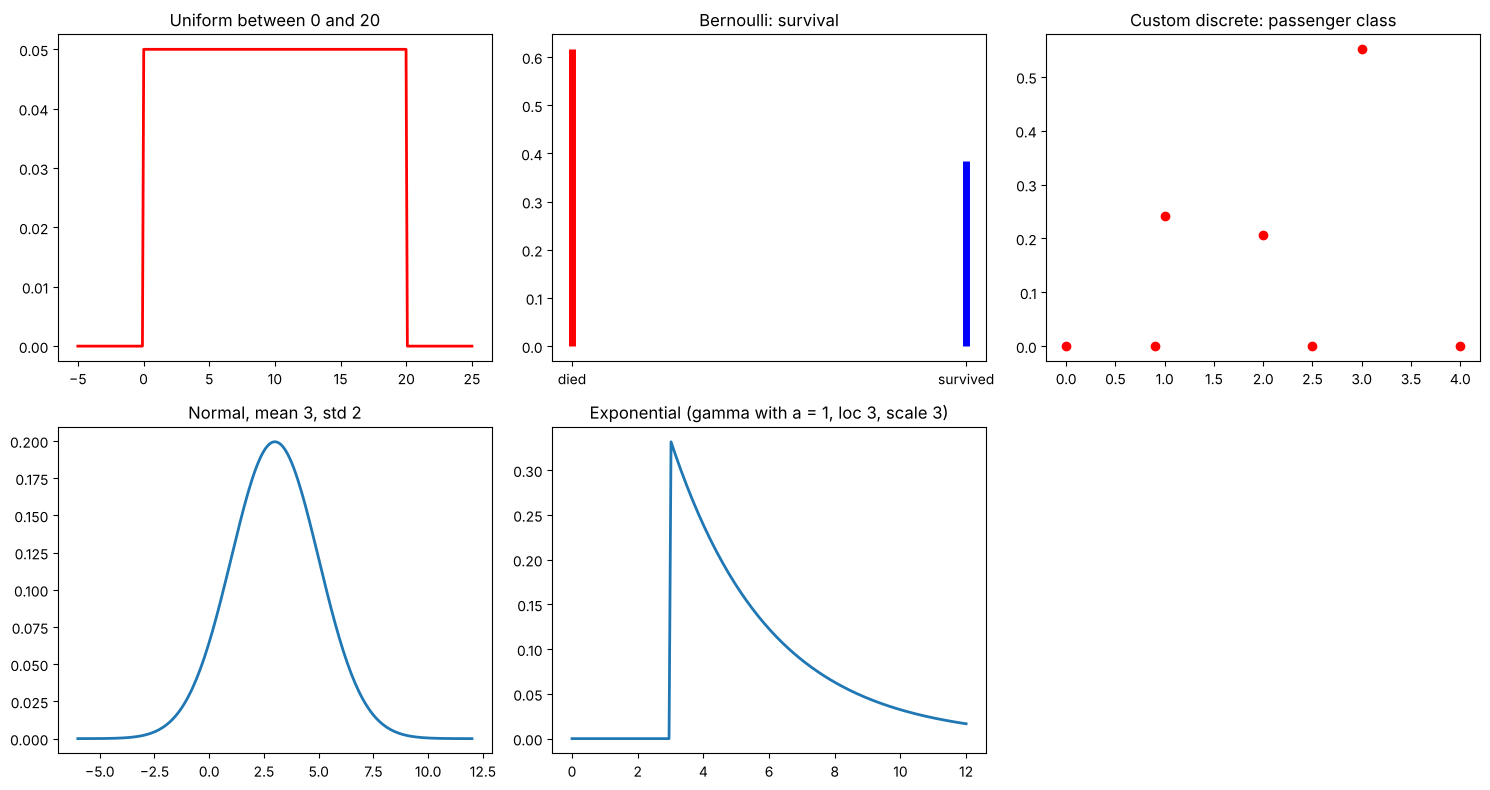

Ten uniform draws: [ 9.99  2.3  17.24 16.75  4.17 19.7  14.07  4.91 16.43  4.32]


In [2]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Uniform between 0 and 20
uniform = stats.uniform(loc=0, scale=20)
x = np.linspace(-5, 25, 300)
axes[0, 0].plot(x, uniform.pdf(x), "r-", lw=2)
axes[0, 0].set_title("Uniform between 0 and 20")

# Bernoulli: P(survived)
survived = stats.bernoulli(titanic["survived"].mean())
axes[0, 1].vlines([0, 1], 0, survived.pmf([0, 1]), colors=["r", "b"], lw=5)
axes[0, 1].set_xticks([0, 1], ["died", "survived"])
axes[0, 1].set_title("Bernoulli: survival")

# Custom discrete distribution: passenger class
pclass = titanic["pclass"].value_counts(normalize=True).sort_index()
pclass_dist = stats.rv_discrete(values=(pclass.index, pclass.values))
k = np.array([0, 0.9, 1, 2, 2.5, 3, 4])
axes[0, 2].plot(k, pclass_dist.pmf(k), "ro")
axes[0, 2].set_title("Custom discrete: passenger class")

# Normal with mean 3 and standard deviation 2
x = np.linspace(-6, 12, 200)
axes[1, 0].plot(x, stats.norm(loc=3, scale=2).pdf(x), lw=2)
axes[1, 0].set_title("Normal, mean 3, std 2")

# Exponential = gamma with a = 1
x = np.linspace(0, 12, 200)
axes[1, 1].plot(x, stats.gamma(a=1, loc=3, scale=3).pdf(x), lw=2)
axes[1, 1].set_title("Exponential (gamma with a = 1, loc 3, scale 3)")

axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

print("Ten uniform draws:", uniform.rvs(size=10, random_state=rng).round(2))

## Fitting passenger ages

Fit a distribution by maximum likelihood, overlay it on the histogram and the empirical CDF, and run a
Kolmogorov-Smirnov test of the fit.

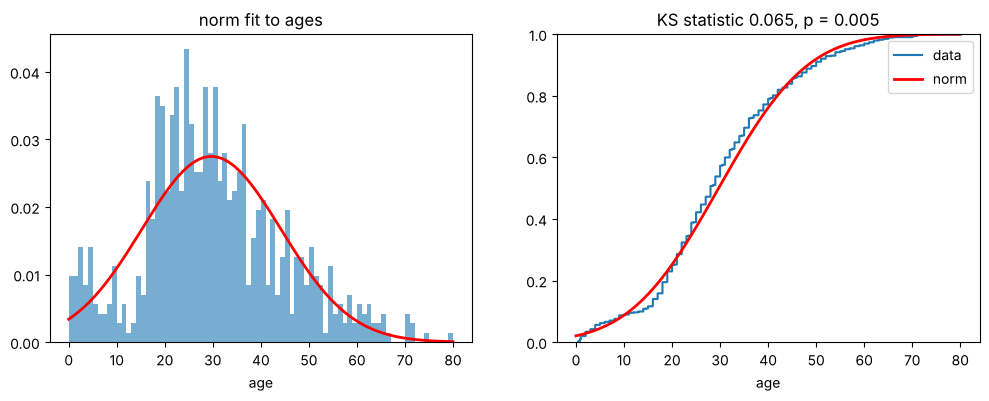

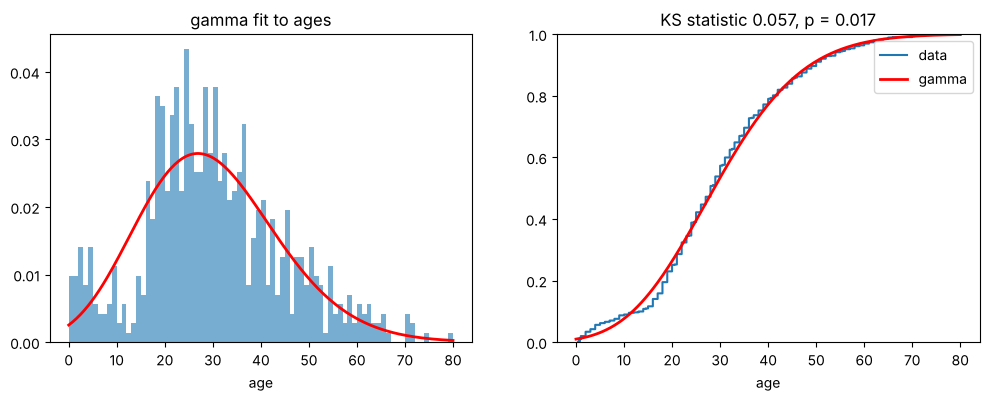

In [3]:
def fit_and_plot(dist, data=ages):
    """Fit `dist` to `data`, plot pdf and cdf against the data, return the frozen fit and KS result."""
    fitted = dist(*dist.fit(data))
    ks = stats.kstest(data, fitted.cdf)

    x = np.linspace(0, 80, 200)
    fig, (ax_pdf, ax_cdf) = plt.subplots(1, 2, figsize=(12, 4))
    ax_pdf.hist(data, bins=80, range=(0, 80), density=True, alpha=0.6)
    ax_pdf.plot(x, fitted.pdf(x), "r-", lw=2)
    ax_pdf.set_title(f"{dist.name} fit to ages")
    ax_cdf.ecdf(data, label="data")
    ax_cdf.plot(x, fitted.cdf(x), "r-", lw=2, label=dist.name)
    ax_cdf.set_title(f"KS statistic {ks.statistic:.3f}, p = {ks.pvalue:.2g}")
    ax_cdf.legend()
    for ax in (ax_pdf, ax_cdf):
        ax.set_xlabel("age")
    plt.show()
    return fitted, ks


fit_and_plot(stats.norm)
fit_and_plot(stats.gamma);

Neither fits well: the age distribution has a bump of young children that a single smooth distribution misses,
and with ~700 ages the KS test has the power to see it.

## Monte Carlo risk estimate

A project saves money per unit in three ways, each known only as a 90% confidence range, and the production level
is also uncertain. A 90% range for a normal spans ±1.645σ, so σ = (high − low) / 3.29.
What is the probability that total savings fall below $400,000?

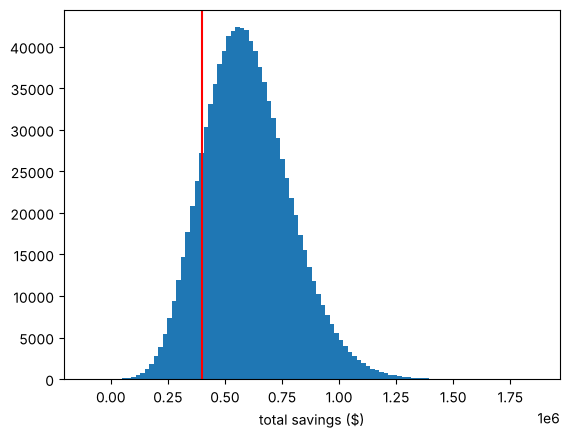

P(total savings < $400,000) = 14.08%


In [4]:
Z90 = 3.29  # width of a 90% interval, in standard deviations


def from_90_interval(low, high):
    return stats.norm(loc=(low + high) / 2, scale=(high - low) / Z90)


n_sims = 1_000_000
inputs = {
    "maintenance_savings_per_unit": from_90_interval(10, 20),
    "labor_savings_per_unit": from_90_interval(-2, 8),
    "raw_materials_savings_per_unit": from_90_interval(3, 9),
    "production_level": from_90_interval(15_000, 35_000),
}
sims = pd.DataFrame({name: dist.rvs(n_sims, random_state=rng) for name, dist in inputs.items()})
sims["total_savings"] = sims.filter(like="per_unit").sum(axis=1) * sims["production_level"]

target = 400_000
plt.hist(sims["total_savings"], bins=100)
plt.axvline(x=target, c="r")
plt.xlabel("total savings ($)")
plt.show()
print(f"P(total savings < ${target:,}) = {(sims['total_savings'] < target).mean():.2%}")